# SAR L2 Validation — Steps 4 & 5

This notebook demonstrates:
- **Step 4a** — SAR patch extraction (`collocation_patches.nc`)
- **Step 4b** — Validation statistics (bias, RMSE, correlation)
- **Step 5**  — Visualisation (scatter, geographic, statistics bar chart, residuals)

Prerequisites: steps 1–3 must already have been run (i.e. `datatree.nc` and
`collocation_results.nc` must exist in the data directory).

In [1]:
import xarray as xr
from pathlib import Path

# ── Edit this path to match your data directory ──────────────────────────────
DATA_DIR = Path(
    "/home/chvan0015/git/sar-l2-validation-toolbox/data/"
    "2026-03-01-000000-2026-03-02-000000_-10.00_5.00_50.00_65.00"
)
RECIPE_PATH = Path("/home/chvan0015/git/sar-l2-validation-toolbox/recipes/test.yaml")
# ─────────────────────────────────────────────────────────────────────────────

print("Data directory:", DATA_DIR)
print("Files present:", [f.name for f in DATA_DIR.iterdir() if f.is_file()])

Data directory: /home/chvan0015/git/sar-l2-validation-toolbox/data/2026-03-01-000000-2026-03-02-000000_-10.00_5.00_50.00_65.00
Files present: ['collocation_results.nc', 'validation_statistics_owiWindSpeed_vs_WSPD.nc', 'collocation_patches.nc', 'validation_statistics_owiWindSpeed_vs_WSPD.csv', 'validation_statistics_owiWindDirection_vs_WDIR.csv', 'validation_statistics_owiWindDirection_vs_WDIR.nc', 'datatree.nc', 'download_metadata.json']


## Load DataTree and collocation results

In [2]:
datatree = xr.open_datatree(str(DATA_DIR / "datatree.nc"), engine="netcdf4")
collocation_ds = xr.open_dataset(str(DATA_DIR / "collocation_results.nc"))

print("DataTree structure:")
print(datatree)
print("\nCollocation dataset:")
print(collocation_ds)

DataTree structure:
<xarray.DataTree>
Group: /
├── Group: /sar
│   ├── Group: /sar/S1A_IW_OCN__2SDV_20260301T171935_20260301T172000_063437_07F82A_AAD8.SAFE
│   │       Dimensions:                (y: 166, x: 263)
│   │       Coordinates:
│   │           lon                    (y, x) float32 175kB ...
│   │           lat                    (y, x) float32 175kB ...
│   │           time                   datetime64[ns] 8B ...
│   │       Dimensions without coordinates: y, x
│   │       Data variables:
│   │           owiRadVel              (y, x) float32 175kB ...
│   │           owiIncidenceAngle      (y, x) float32 175kB ...
│   │           owiElevationAngle      (y, x) float32 175kB ...
│   │           owiWindSpeed           (y, x) float32 175kB ...
│   │           owiWindDirection       (y, x) float32 175kB ...
│   │           owiEcmwfWindSpeed      (y, x) float32 175kB ...
│   │           owiEcmwfWindDirection  (y, x) float32 175kB ...
│   │           owiNrcsCmod            (y, x) flo

In [3]:
# Inspect available variables
print("Collocation variables:")
for v in sorted(collocation_ds.data_vars):
    print(f"  {v}: {collocation_ds[v].dtype}")

Collocation variables:
  collocation_type: <U14
  sar_lat: float64
  sar_lon: float64
  sar_owiEcmwfWindDirection: float64
  sar_owiEcmwfWindSpeed: float64
  sar_owiElevationAngle: float64
  sar_owiHeading: float64
  sar_owiIncidenceAngle: float64
  sar_owiInversionQuality: float64
  sar_owiMask: float64
  sar_owiNrcsCmod: float64
  sar_owiRadVel: float64
  sar_owiWindDirection: float64
  sar_owiWindQuality: float64
  sar_owiWindSpeed: float64
  sar_scene_name: <U72
  sar_x_idx: int64
  sar_y_idx: int64
  spatial_distance_km: float64
  temporal_distance_minutes: float64
  val_EWCT: float64
  val_HCDT: float64
  val_HCSP: float64
  val_NSCT: float64
  val_VAVH: float64
  val_WDIR: float64
  val_WSPD: float64
  val_depth: float64
  val_lat: float64
  val_lon: float64
  val_source: <U6


## Load recipe

In [4]:
from sar_validation.core.recipe import Recipe

recipe = Recipe.from_yaml(RECIPE_PATH)
print(f"Recipe: {recipe.config.name}")
print(f"Variable: {recipe.config.variable}")

Recipe: test
Variable: wind


## Step 4a — SAR patch extraction

Extract a 5×5 pixel neighbourhood from the SAR swath around each collocated point.
The result is saved to `collocation_patches.nc`.

<xarray.Dataset> Size: 537MB
Dimensions:                          (collocation: 174677, patch_y: 5,
                                      patch_x: 5)
Coordinates:
    time                             (collocation) datetime64[ns] 1MB ...
    val_time                         (collocation) datetime64[ns] 1MB ...
    val_id                           (collocation) <U16 11MB ...
  * patch_y                          (patch_y) int64 40B -2 -1 0 1 2
  * patch_x                          (patch_x) int64 40B -2 -1 0 1 2
Dimensions without coordinates: collocation
Data variables: (12/43)
    sar_lon                          (collocation) float64 1MB ...
    sar_lat                          (collocation) float64 1MB ...
    val_lon                          (collocation) float64 1MB ...
    val_lat                          (collocation) float64 1MB ...
    spatial_distance_km              (collocation) float64 1MB ...
    temporal_distance_minutes        (collocation) float64 1MB ...
    ...         

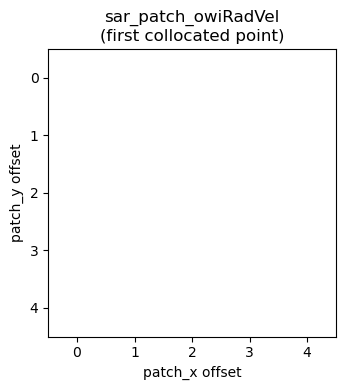

In [5]:
from sar_validation.core.patch_extractor import run_patch_extraction

PATCH_SIZE = 5  # pixels; must be odd

patches_ds = run_patch_extraction(
    collocation_ds=collocation_ds,
    datatree=datatree,
    patch_size=PATCH_SIZE,
    base_dir=DATA_DIR,
)

if patches_ds is not None:
    print(patches_ds)
    # Show the first patch for the first SAR variable
    patch_vars = [v for v in patches_ds.data_vars if v.startswith("sar_patch_")]
    if patch_vars:
        import matplotlib.pyplot as plt
        v = patch_vars[0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(patches_ds[v].isel(collocation=0).values, origin="upper", cmap="viridis")
        ax.set_title(f"{v}\n(first collocated point)")
        ax.set_xlabel("patch_x offset")
        ax.set_ylabel("patch_y offset")
        plt.tight_layout()
        plt.show()

## Step 4b — Validation statistics

In [6]:
from sar_validation.core.statistics import run_statistics

stats_map = run_statistics(collocation_ds, recipe, DATA_DIR)

for key, ds in stats_map.items():
    print(f"\n── {key} ──")
    print(ds.to_dataframe())


── owiWindSpeed_vs_WSPD ──
            N      bias      std      rmse  correlation  scatter_index
source                                                                
insitu  72000  1.452728  3.49092  3.781107     0.023663       0.338236

── owiWindDirection_vs_WDIR ──
            N      bias       std       rmse  correlation  scatter_index
source                                                                  
insitu  71962  8.902019  11.93943  14.892749     0.144474       0.102961


## Step 5 — Visualisation

### 5a. Scatter plot

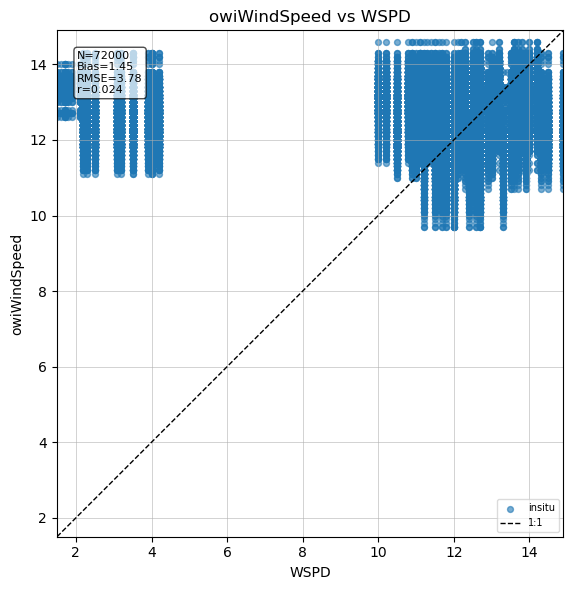

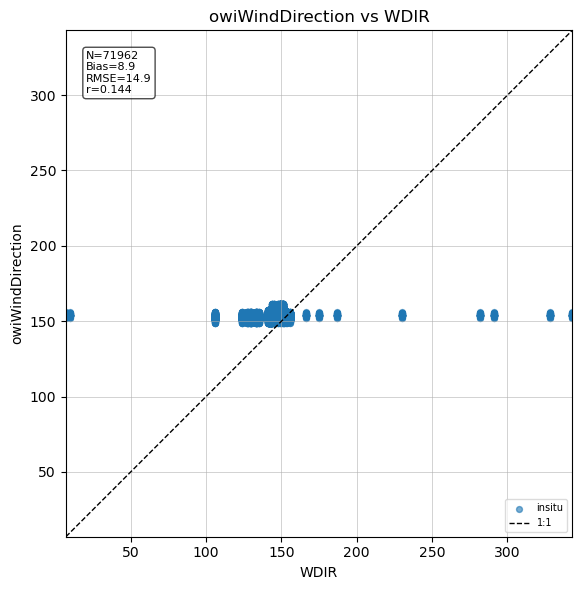

In [7]:
from sar_validation.core.visualization import plot_scatter
from sar_validation.core._variable_map import infer_variable_pairs
import matplotlib.pyplot as plt

pairs = infer_variable_pairs(recipe.config.variable)

for sar_var, val_var in pairs:
    fig = plot_scatter(collocation_ds, sar_var, val_var, by_source=True)
    if fig:
        plt.show()

### 5b. Interactive scatter (requires plotly)

In [8]:
try:
    for sar_var, val_var in pairs:
        fig = plot_scatter(collocation_ds, sar_var, val_var, interactive=True)
        if fig:
            fig.show()
except ImportError as e:
    print(f"Skipping interactive scatter: {e}")

Skipping interactive scatter: Package 'plotly' is required for interactive plots. Install it with:  pip install 'plotly'  or  pip install 'sar-l2-validation-toolbox[plot]'


### 5c. Geographic plot — one subplot per SAR scene

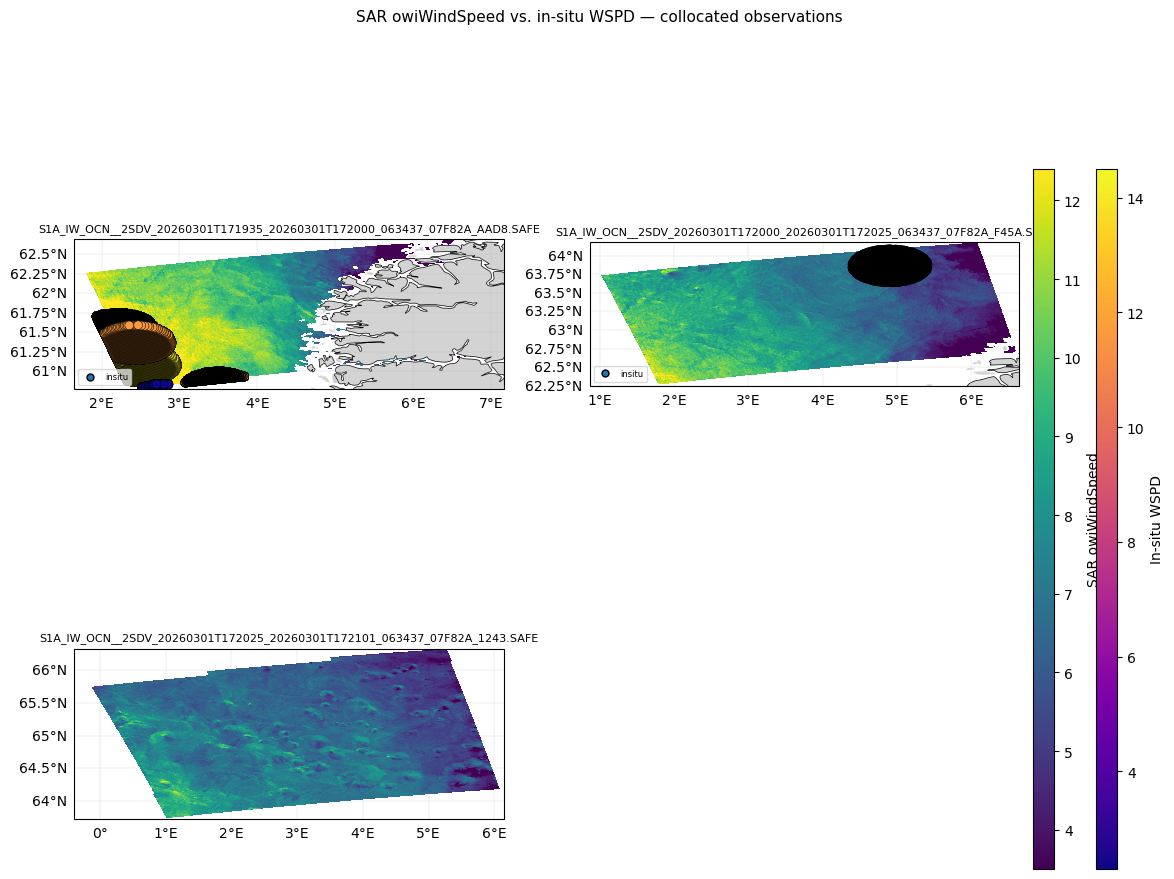

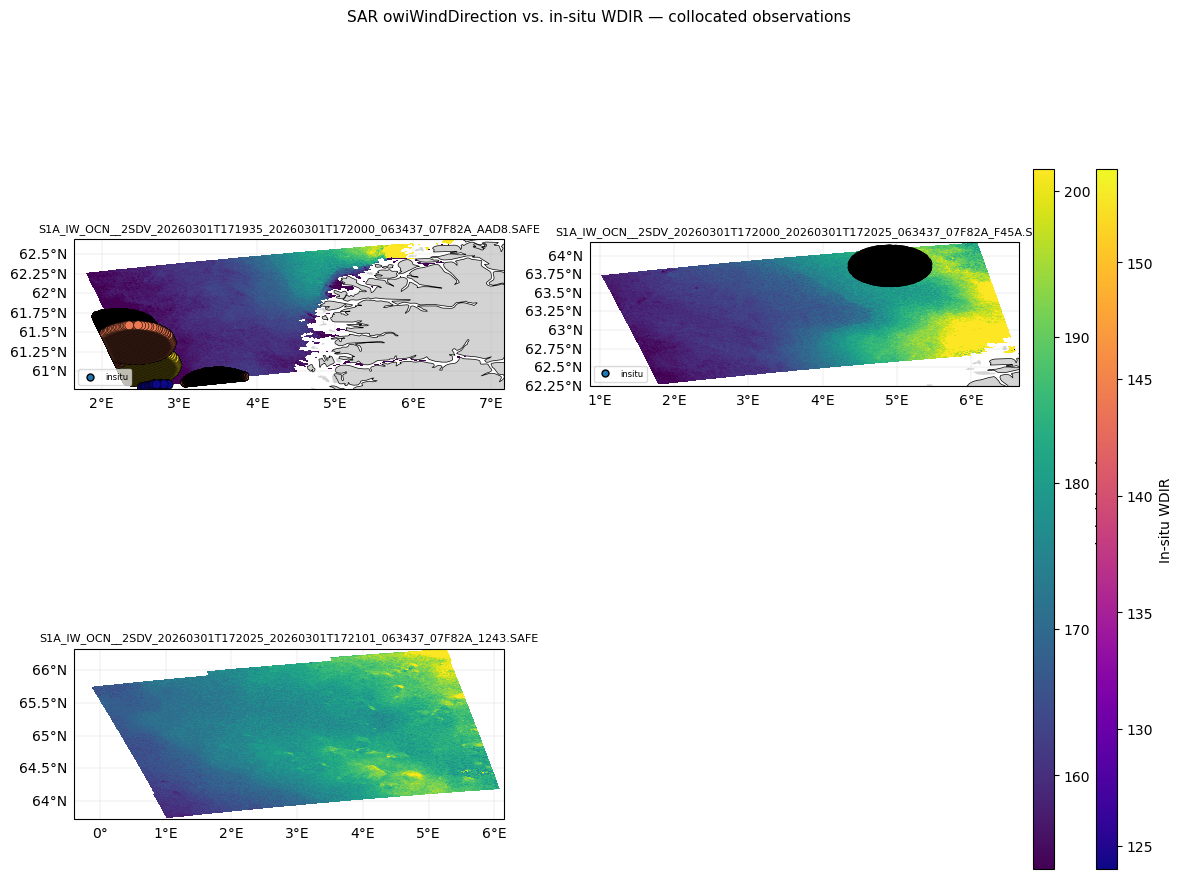

In [ ]:
from sar_validation.core.visualization import plot_geographic

for sar_var, val_var in pairs:
    try:
        # Returns dict[collocation_type → Figure] by default (split_by="collocation_type")
        result = plot_geographic(datatree, collocation_ds, sar_var, val_var, ncols=2)
        if isinstance(result, dict):
            for group_name, fig in result.items():
                print(f"  {sar_var} [{group_name}]")
                plt.show()
                plt.close(fig)
        elif result:
            plt.show()
    except Exception as e:
        print(f"Geographic plot failed for {sar_var}: {e}")


### 5d. Interactive geographic map (requires folium)

In [10]:
try:
    for sar_var, val_var in pairs:
        m = plot_geographic(datatree, collocation_ds, sar_var, interactive=True)
        display(m)  # renders inline in Jupyter
except ImportError as e:
    print(f"Skipping interactive map: {e}")
except Exception as e:
    print(f"Interactive map failed: {e}")

Skipping interactive map: Package 'folium' is required for interactive plots. Install it with:  pip install 'folium'  or  pip install 'sar-l2-validation-toolbox[plot]'


### 5e. Statistics bar chart

/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)


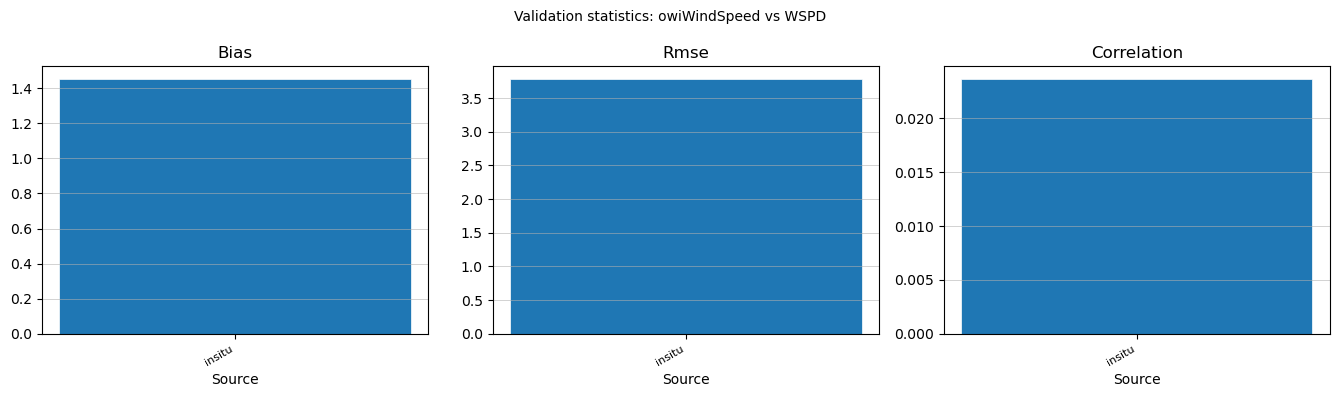

/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)


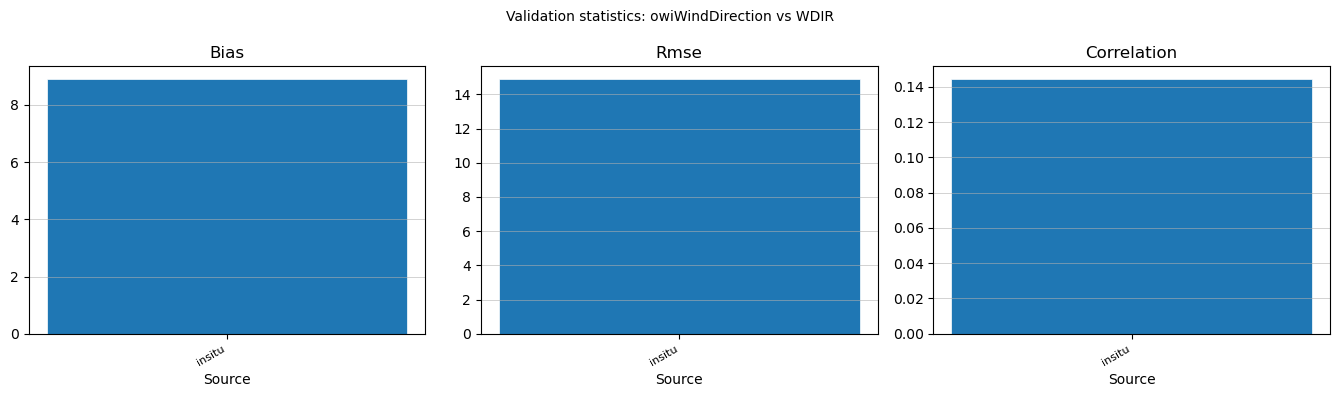

In [11]:
from sar_validation.core.visualization import plot_statistics

for key, stats_ds in stats_map.items():
    fig = plot_statistics(stats_ds, metrics=["bias", "rmse", "correlation"])
    if fig:
        plt.show()

### 5f. Residuals histogram

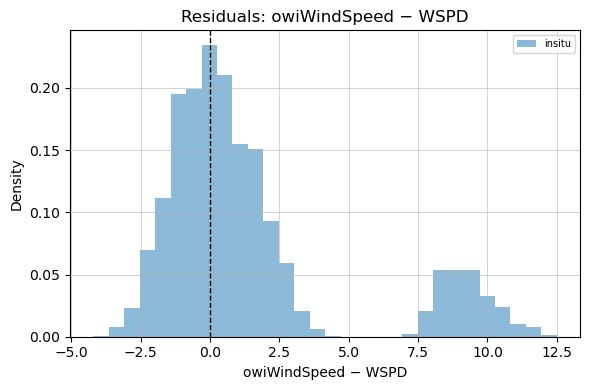

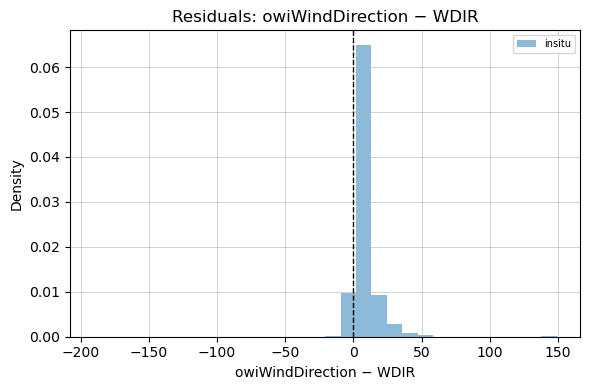

In [12]:
from sar_validation.core.visualization import plot_residuals

for sar_var, val_var in pairs:
    fig = plot_residuals(collocation_ds, sar_var, val_var, by_source=True)
    if fig:
        plt.show()

### 5g. Full validation report

Run all plots at once and save PNGs to `<data_dir>/plots/`.

/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:539: UserWarning: set_ticklabels() should only be used with a fixed 

Saved PNG files:
  owiWindDirection_vs_WDIR_geographic.png
  owiWindDirection_vs_WDIR_residuals.png
  owiWindDirection_vs_WDIR_scatter.png
  owiWindDirection_vs_WDIR_statistics.png
  owiWindSpeed_vs_WSPD_geographic.png
  owiWindSpeed_vs_WSPD_residuals.png
  owiWindSpeed_vs_WSPD_scatter.png
  owiWindSpeed_vs_WSPD_statistics.png


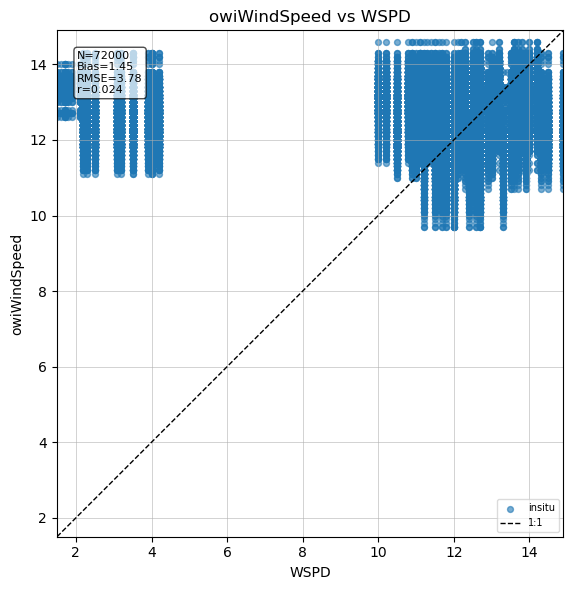

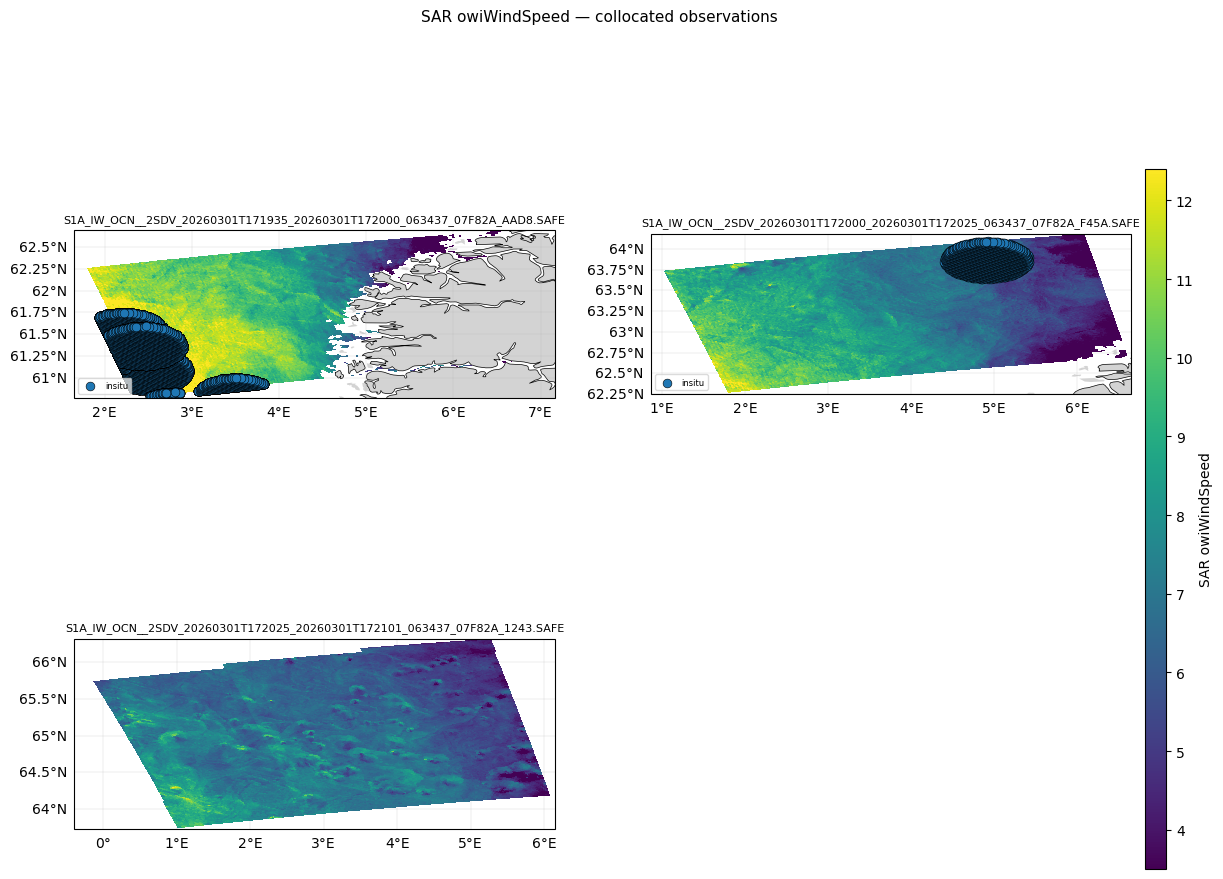

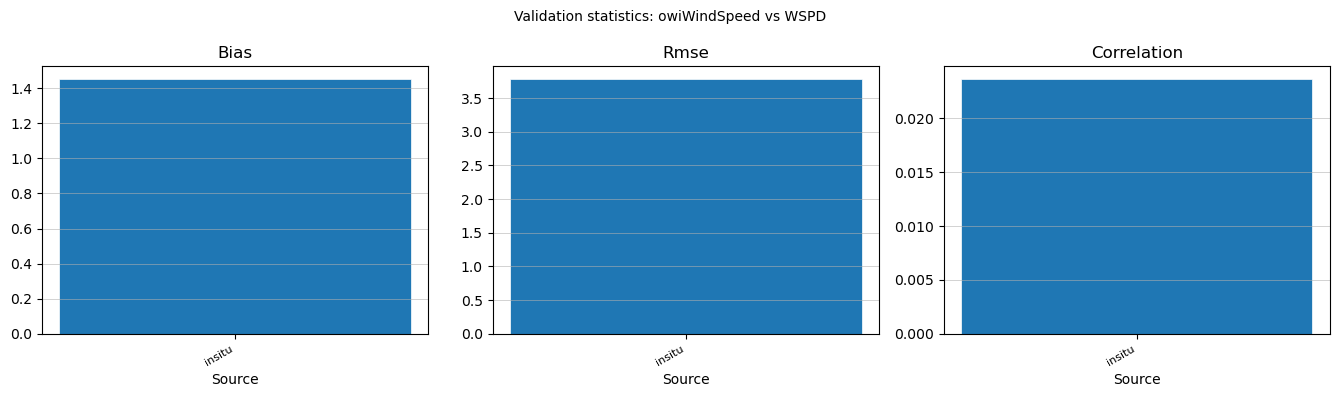

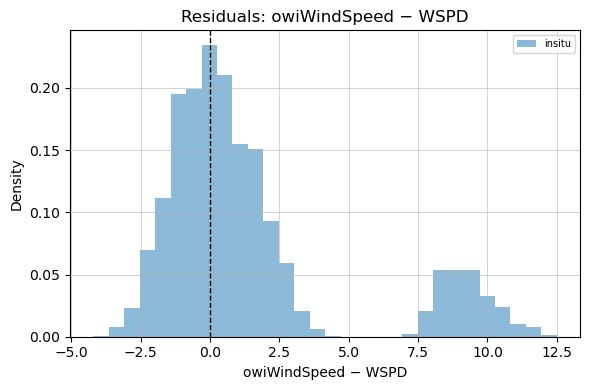

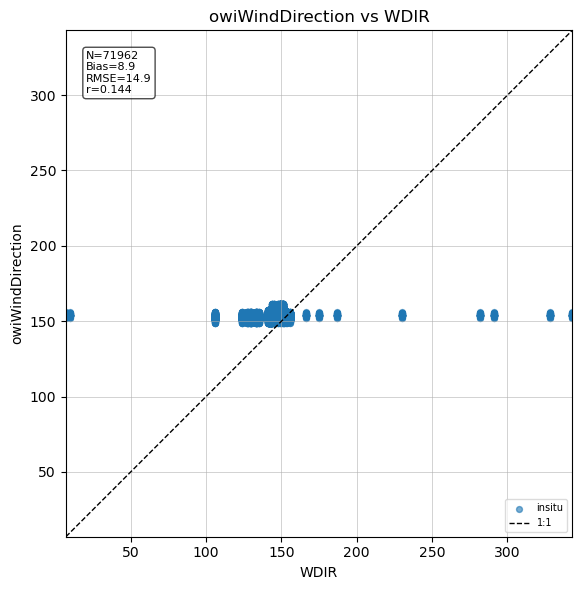

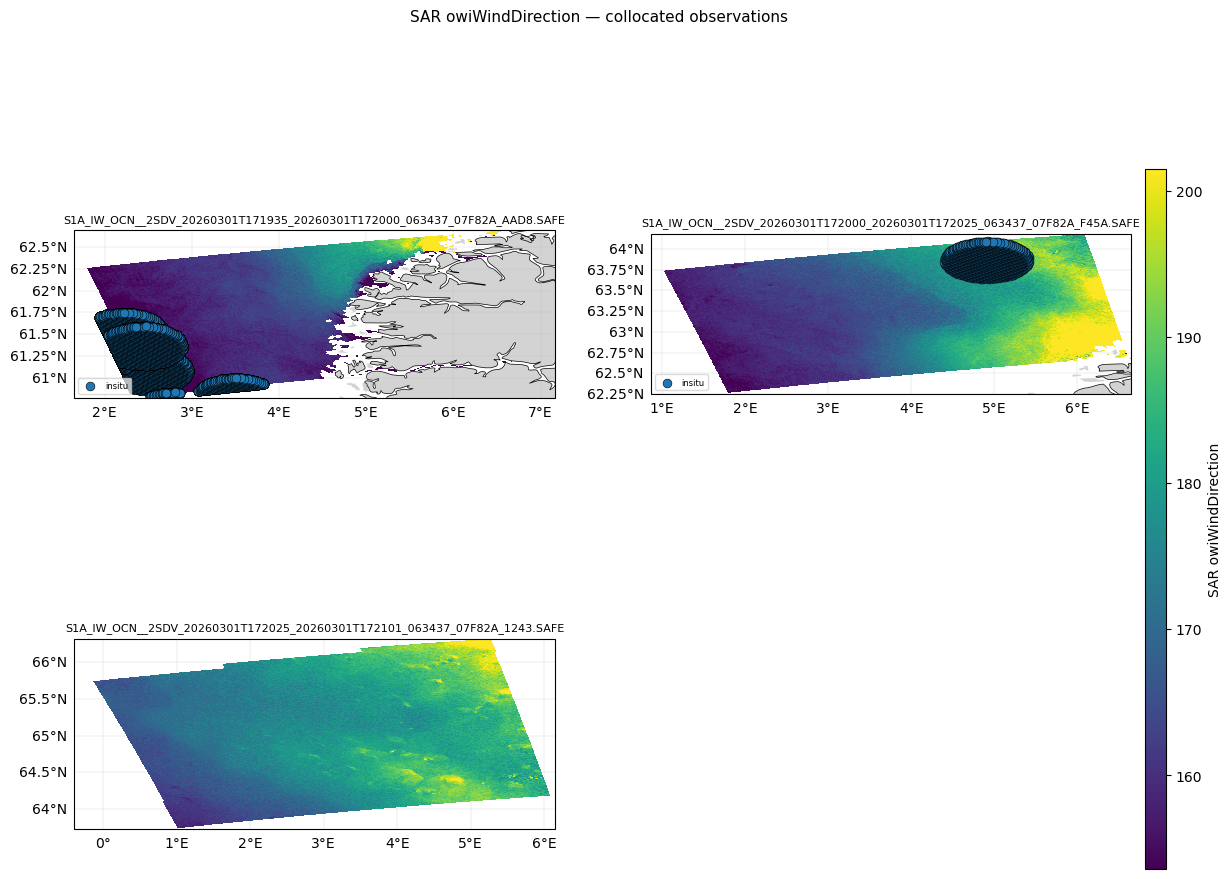

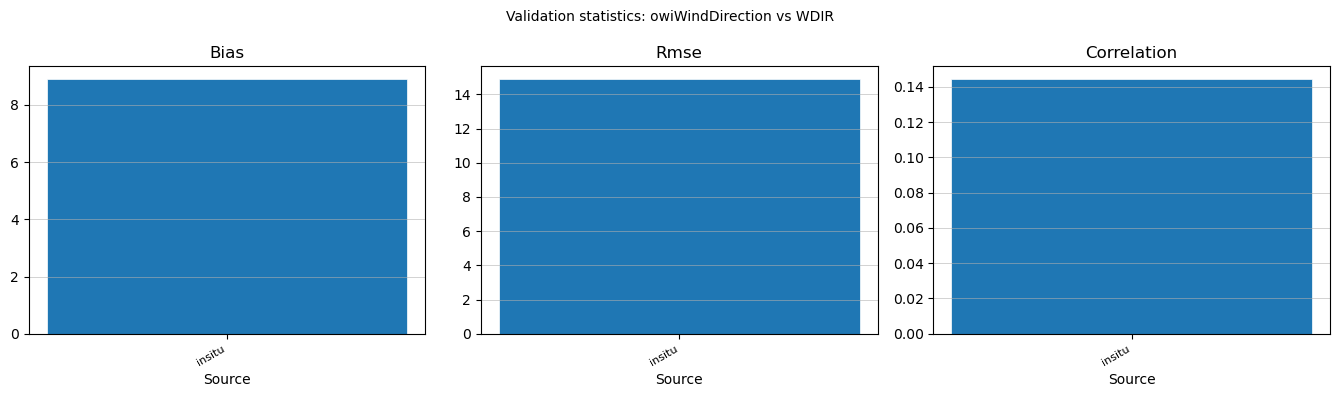

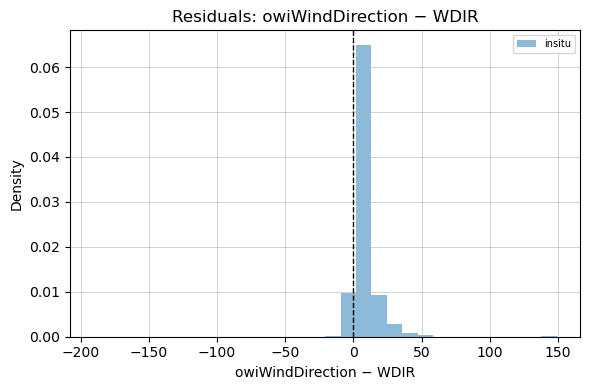

In [13]:
from sar_validation.core.visualization import validation_report

figures = validation_report(
    collocation_ds=collocation_ds,
    datatree=datatree,
    recipe=recipe,
    stats_ds_map=stats_map,
    out_dir=DATA_DIR,
)

print("Saved PNG files:")
for f in sorted((DATA_DIR / "plots").glob("*.png")):
    print(f"  {f.name}")

pdf_path = DATA_DIR / "validation_report.pdf"
if pdf_path.exists():
    print(f"\nPDF report: {pdf_path}")